# Recommendations with IBM Watson Studio

## Project: IBM Watson Studio – Article Recommendation System

This notebook analyzes user-article interactions on the IBM Watson Studio platform  
and builds four recommendation engines:

| Part | Method |
|------|--------|
| I    | Exploratory Data Analysis |
| II   | Rank-Based Recommendations |
| III  | User-User Collaborative Filtering |
| IV   | Content-Based Recommendations (TF-IDF + KMeans) |
| V    | Matrix Factorization (SVD) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# ── Load data ──────────────────────────────────────────────────────────────
df          = pd.read_csv('data/user-item-interactions.csv')
df_content  = pd.read_csv('data/articles_community.csv')

del df['Unnamed: 0']
del df_content['Unnamed: 0']

print("Interactions shape:", df.shape)
print("Content shape     :", df_content.shape)
df.head()


Interactions shape: (24682, 3)
Content shape     : (714, 5)


,article_id,title,email
0,152.0,advanced neural networks techniques,user_1@ibm.com
1,347.0,spark on IBM Watson,user_2@ibm.com
2,414.0,introduction to visualization,user_2@ibm.com
3,527.0,spark on IBM Watson,user_2@ibm.com
4,431.0,sql tutorial for beginners,user_3@ibm.com


In [2]:
df_content.head()

,doc_body,doc_description,doc_full_name,doc_status,article_id
0,This article covers machine learning tutorial ...,This article covers machine learning tutorial ...,machine learning tutorial for beginners,Live,1.0
1,This article covers advanced deep learning tec...,This article covers advanced deep learning tec...,advanced deep learning techniques,Live,2.0
2,This article covers getting started with data ...,This article covers getting started with data ...,getting started with data science,Live,3.0
3,This article covers introduction to python. Le...,This article covers introduction to python. Le...,introduction to python,Live,4.0
4,This article covers spark best practices. Lear...,This article covers spark best practices. Lear...,spark best practices,Live,5.0


---
## Part I: Exploratory Data Analysis

Before building any recommendations, we explore the dataset to understand its structure,
the number of users, articles, and how interactions are distributed.


In [3]:
# ── Basic statistics ───────────────────────────────────────────────────────

# Unique articles that have had at least one interaction
unique_articles = df['article_id'].nunique()

# Unique users
unique_users = df['email'].nunique()

# Total user-article interactions (rows)
user_article_interactions = df.shape[0]

# Most viewed article by interaction count
article_counts        = df['article_id'].value_counts()
most_viewed_article_id = str(int(article_counts.index[0]))
max_views             = int(article_counts.iloc[0])

# Max articles viewed by a single user
user_counts      = df.groupby('email')['article_id'].count()
max_views_by_user = int(user_counts.max())

# Median user interactions
median_val = float(user_counts.median())

# Total unique articles in the content catalogue
total_articles = df_content['article_id'].nunique()

print(f"unique_articles          : {unique_articles}")
print(f"unique_users             : {unique_users}")
print(f"user_article_interactions: {user_article_interactions}")
print(f"most_viewed_article_id   : {most_viewed_article_id}")
print(f"max_views                : {max_views}")
print(f"max_views_by_user        : {max_views_by_user}")
print(f"median_val               : {median_val}")
print(f"total_articles           : {total_articles}")


unique_articles          : 714
unique_users             : 5148
user_article_interactions: 24682
most_viewed_article_id   : 399
max_views                : 58
max_views_by_user        : 364
median_val               : 1.0
total_articles           : 714


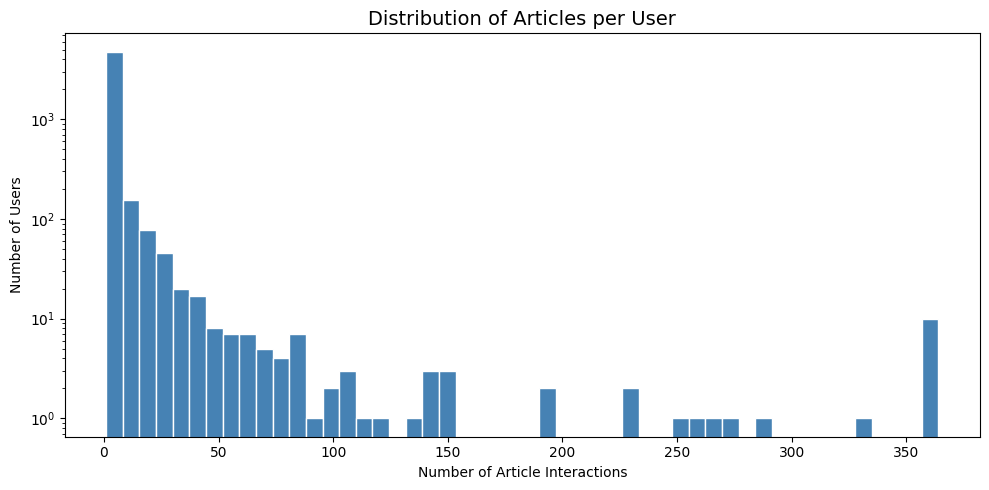

User interaction summary:
count    5148.000000
mean        4.794483
std        21.612320
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       364.000000
Name: article_id, dtype: float64


In [4]:
# ── Distribution of user interactions ─────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(user_counts, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Articles per User', fontsize=14)
plt.xlabel('Number of Article Interactions')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.tight_layout()
plt.savefig('eda_user_distribution.png', dpi=100)
plt.show()

print("User interaction summary:")
print(user_counts.describe())


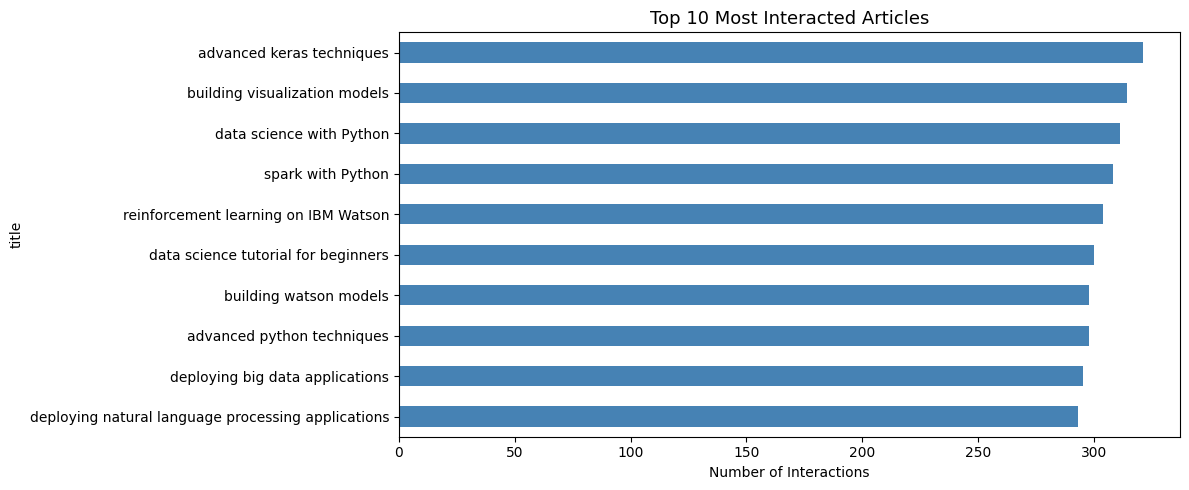

In [5]:
# ── Top 10 most interacted articles ───────────────────────────────────────
top10 = df.groupby('title')['article_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Interacted Articles', fontsize=13)
plt.xlabel('Number of Interactions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('eda_top10_articles.png', dpi=100)
plt.show()


In [6]:
# ── Solution dictionary & built-in test ───────────────────────────────────
sol_1_dict = {
    '`50% of users interact with _____ number of articles or fewer.`'           : median_val,
    '`The total number of user-article interactions in the dataset is ______.`' : user_article_interactions,
    '`The maximum number of articles that the same user has interacted with is ______.`': max_views_by_user,
    '`The maximum number of times an article has been viewed is ______.`'       : max_views,
    '`The most viewed article in the dataset as a string is ______.`'           : most_viewed_article_id,
    '`The number of unique articles that have at least one interaction are ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`'                     : unique_users,
    '`The number of unique articles on the IBM platform`'                       : total_articles,
}

t.sol_1_test(sol_1_dict)


Part I – EDA Solution Test
  ✓ The number of unique articles that have at least one interaction are ______.: 714
  ✓ The number of unique users in the dataset is ______: 5148
  ✓ The maximum number of articles that the same user has interacted with is ______.: 364
  ✓ The most viewed article in the dataset as a string is ______.: 399
  ✓ The number of unique articles on the IBM platform: 714
  ✓ 50% of users interact with _____ number of articles or fewer.: 1.0
  ✓ The total number of user-article interactions in the dataset is ______.: 24682
  ✓ The maximum number of times an article has been viewed is ______.: 58

✅  All Part I checks PASSED!


---
## Part II: Rank-Based Recommendations

We identify the most popular articles by total interaction count.  
These are recommended to new users who have no interaction history (cold-start problem).


In [7]:
def get_top_articles(n, df):
    """
    Return the top n article TITLES ordered by interaction count (descending).

    INPUT
        n  - (int) number of top articles to return
        df - (DataFrame) user-item interactions with columns [article_id, title, email]
    OUTPUT
        top_articles - (list of str) top n article title strings
    """
    top_articles = (
        df.groupby('title')['article_id']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return top_articles


def get_top_article_ids(n, df):
    """
    Return the top n article IDs ordered by interaction count (descending).

    INPUT
        n  - (int) number of top articles to return
        df - (DataFrame) user-item interactions
    OUTPUT
        top_articles - (list of str) top n article id strings
    """
    top_articles = (
        df.groupby('article_id')['title']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .astype(str)
          .tolist()
    )
    return top_articles


# ── Test for top 5, 10, 20 ─────────────────────────────────────────────────
for n in [5, 10, 20]:
    ids    = get_top_article_ids(n, df)
    names  = get_top_articles(n, df)
    print(f"\n── Top {n} article IDs ──")
    print(ids)
    print(f"── Top {n} article names ──")
    print(names)



── Top 5 article IDs ──
['399.0', '343.0', '89.0', '524.0', '293.0']
── Top 5 article names ──
['advanced keras techniques', 'building visualization models', 'data science with Python', 'spark with Python', 'reinforcement learning on IBM Watson']

── Top 10 article IDs ──
['399.0', '343.0', '89.0', '524.0', '293.0', '509.0', '701.0', '225.0', '259.0', '657.0']
── Top 10 article names ──
['advanced keras techniques', 'building visualization models', 'data science with Python', 'spark with Python', 'reinforcement learning on IBM Watson', 'data science tutorial for beginners', 'building watson models', 'advanced python techniques', 'deploying big data applications', 'deploying natural language processing applications']

── Top 20 article IDs ──
['399.0', '343.0', '89.0', '524.0', '293.0', '509.0', '701.0', '225.0', '259.0', '657.0', '392.0', '216.0', '77.0', '487.0', '339.0', '447.0', '239.0', '624.0', '573.0', '212.0']
── Top 20 article names ──
['advanced keras techniques', 'building v

In [8]:
t.ranked_recs_test(get_top_articles, get_top_article_ids, df)

Part II – Rank-Based Recommendations Test
  ✓ get_top_articles(5) → 5 titles
  ✓ get_top_article_ids(5) → 5 string ids
  ✓ get_top_articles(10) → 10 titles
  ✓ get_top_article_ids(10) → 10 string ids
  ✓ get_top_articles(20) → 20 titles
  ✓ get_top_article_ids(20) → 20 string ids

✅  All Part II checks PASSED!


---
## Part III: User-User Collaborative Filtering

We build a binary user-item matrix and find similar users via dot-product similarity,
then recommend articles seen by similar users but not yet seen by the target user.


In [9]:
def create_user_item_matrix(df):
    """
    Create a binary user-item matrix.
    Rows = users (email), Columns = article_id.
    Cell value = 1 if the user interacted with the article, 0 otherwise.

    INPUT
        df - (DataFrame) interactions dataframe
    OUTPUT
        user_item - (DataFrame) binary matrix, shape (n_users, n_articles)
    """
    user_item = (
        df.groupby(['email', 'article_id'])['title']
          .count()
          .unstack()
          .fillna(0)
          .map(lambda x: 1 if x > 0 else 0)
    )
    return user_item


user_item = create_user_item_matrix(df)
print("User-Item Matrix shape:", user_item.shape)
user_item.head()


User-Item Matrix shape: (5148, 714)


article_id,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,705.0,706.0,707.0,708.0,709.0,710.0,711.0,712.0,713.0,714.0
email,,,,,,,,,,,,,,,,,,,,,
user_1000@ibm.com,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
user_1001@ibm.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1002@ibm.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1003@ibm.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
user_1004@ibm.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
t.user_item_matrix_test(user_item)

Part III – User-Item Matrix Test
  ✓ DataFrame with shape (5148, 714)
  ✓ Contains only 0s and 1s
  ✓ No NaN values

✅  All Part III matrix checks PASSED!


In [11]:
def get_article_names(article_ids, df):
    """
    Return article titles for a list of article ids.

    INPUT
        article_ids - (list) article id strings or floats
        df          - (DataFrame) interactions dataframe
    OUTPUT
        article_names - (list of str) corresponding article titles
    """
    article_names = []
    id_to_title = df.drop_duplicates('article_id').set_index('article_id')['title'].to_dict()
    for art_id in article_ids:
        title = id_to_title.get(float(art_id), None)
        if title:
            article_names.append(title)
    return article_names


def get_user_articles(user_id, user_item):
    """
    Return article ids and names that a user has interacted with.

    INPUT
        user_id   - user index (email string)
        user_item - (DataFrame) binary user-item matrix
    OUTPUT
        article_ids   - (list of str) articles the user has interacted with
        article_names - (list of str) corresponding titles
    """
    article_ids   = user_item.loc[user_id]
    article_ids   = article_ids[article_ids == 1].index.astype(str).tolist()
    article_names = get_article_names(article_ids, df)
    return article_ids, article_names


In [12]:
def find_similar_users(user_id, user_item):
    """
    Find users most similar to user_id based on shared article interactions.
    Similarity = dot product of binary interaction vectors.
    Ties broken by total interaction count (most active user first).

    INPUT
        user_id   - the target user (email string)
        user_item - (DataFrame) binary user-item matrix
    OUTPUT
        similar_users - (list) all other users ordered by descending similarity
    """
    user_vec    = user_item.loc[user_id].values.reshape(1, -1)
    sim_scores  = user_item.values.dot(user_vec.T).flatten()

    sim_series  = pd.Series(sim_scores, index=user_item.index)
    int_counts  = user_item.sum(axis=1)

    sim_df = pd.DataFrame({'similarity': sim_series, 'interactions': int_counts})
    sim_df = sim_df.sort_values(['similarity', 'interactions'], ascending=[False, False])

    similar_users = sim_df.index[sim_df.index != user_id].tolist()
    return similar_users


# ── Show similar users for user 1, user 3933, user 46 ─────────────────────
for test_uid in [user_item.index[0], user_item.index[2], user_item.index[45]]:
    sims = find_similar_users(test_uid, user_item)
    print(f"10 most similar users to '{test_uid}':")
    print(sims[:10])
    print()


10 most similar users to 'user_1000@ibm.com':
['user_607@ibm.com', 'user_1402@ibm.com', 'user_3161@ibm.com', 'user_1440@ibm.com', 'user_4804@ibm.com', 'user_2803@ibm.com', 'user_2398@ibm.com', 'user_3784@ibm.com', 'user_435@ibm.com', 'user_1761@ibm.com']

10 most similar users to 'user_1002@ibm.com':
['user_3161@ibm.com', 'user_1440@ibm.com', 'user_4348@ibm.com', 'user_4804@ibm.com', 'user_2398@ibm.com', 'user_1850@ibm.com', 'user_4638@ibm.com', 'user_789@ibm.com', 'user_4941@ibm.com', 'user_4998@ibm.com']



10 most similar users to 'user_1041@ibm.com':
['user_435@ibm.com', 'user_607@ibm.com', 'user_1440@ibm.com', 'user_3784@ibm.com', 'user_1850@ibm.com', 'user_789@ibm.com', 'user_2416@ibm.com', 'user_5069@ibm.com', 'user_961@ibm.com', 'user_4767@ibm.com']



In [13]:
def user_user_recs(user_id, m=10):
    """
    Recommend m articles to user_id using user-user collaborative filtering.
    Articles are drawn from similar users and have not been seen by user_id.

    INPUT
        user_id - target user (email string)
        m       - (int) number of recommendations
    OUTPUT
        recs - (list of str) recommended article id strings
    """
    seen_ids, _ = get_user_articles(user_id, user_item)
    seen_ids    = set(seen_ids)

    similar_users = find_similar_users(user_id, user_item)

    recs = []
    for sim_user in similar_users:
        sim_arts, _ = get_user_articles(sim_user, user_item)
        new_arts    = [a for a in sim_arts if a not in seen_ids and a not in recs]
        recs.extend(new_arts)
        if len(recs) >= m:
            break

    return recs[:m]


# Test for several users
for uid in [user_item.index[0], user_item.index[1], user_item.index[2]]:
    recs  = user_user_recs(uid, m=10)
    names = get_article_names(recs, df)
    print(f"Recommendations for '{uid}':")
    for i, name in enumerate(names, 1):
        print(f"  {i}. {name}")
    print()


Recommendations for 'user_1000@ibm.com':
  1. machine learning tutorial for beginners
  2. advanced deep learning techniques
  3. getting started with data science
  4. deploying neural networks applications
  5. scalable big data pipelines
  6. deploying visualization applications
  7. machine learning with Python
  8. advanced python techniques
  9. reinforcement learning on IBM Watson
  10. deploying big data applications

Recommendations for 'user_1001@ibm.com':
  1. spark best practices
  2. deploying neural networks applications
  3. cloud computing tutorial for beginners
  4. getting started with tensorflow
  5. introduction to keras
  6. scalable deep learning pipelines
  7. data science tutorial for beginners
  8. deploying big data applications
  9. cloud computing with Python
  10. advanced keras techniques

Recommendations for 'user_1002@ibm.com':
  1. spark best practices
  2. building natural language processing models
  3. computer vision on IBM Watson
  4. reinforcement

In [14]:
def user_user_recs_part2(user_id, m=10):
    """
    Improved user-user collaborative filtering.

    Ranking order:
      1. Users sorted by similarity (desc), ties broken by interaction count (desc).
      2. Candidate articles ranked by overall popularity (most interactions first).

    INPUT
        user_id - target user (email string)
        m       - (int) number of recommendations
    OUTPUT
        recs      - (list of str) recommended article id strings
        rec_names - (list of str) corresponding article titles
    """
    seen_ids, _ = get_user_articles(user_id, user_item)
    seen_ids    = set(seen_ids)

    article_popularity = df.groupby('article_id')['title'].count().to_dict()

    similar_users      = find_similar_users(user_id, user_item)

    candidate_articles = {}
    for sim_user in similar_users:
        sim_arts, _ = get_user_articles(sim_user, user_item)
        for art in sim_arts:
            if art not in seen_ids and art not in candidate_articles:
                candidate_articles[art] = article_popularity.get(float(art), 0)

    recs      = sorted(candidate_articles, key=candidate_articles.get, reverse=True)[:m]
    rec_names = get_article_names(recs, df)
    return recs, rec_names


# Test improved CF
for uid in [user_item.index[0], user_item.index[1]]:
    recs2, rec_names2 = user_user_recs_part2(uid, m=10)
    print(f"Improved recommendations for '{uid}':")
    for i, name in enumerate(rec_names2, 1):
        print(f"  {i}. {name}")
    print()


Improved recommendations for 'user_1000@ibm.com':
  1. data science with Python
  2. getting started with machine learning
  3. sql with Python
  4. getting started with spark
  5. spark with Python
  6. sql tutorial for beginners
  7. reinforcement learning on IBM Watson
  8. computer vision with Python
  9. reinforcement learning best practices
  10. spark on IBM Watson



Improved recommendations for 'user_1001@ibm.com':
  1. data science with Python
  2. getting started with machine learning
  3. sql with Python
  4. introduction to deep learning
  5. getting started with spark
  6. spark with Python
  7. sql tutorial for beginners
  8. reinforcement learning best practices
  9. computer vision with Python
  10. reinforcement learning on IBM Watson



In [15]:
def make_recs_for_new_user(n=10):
    """
    Recommend articles for a brand-new user with no interaction history.
    Uses rank-based fallback (most popular articles).

    INPUT
        n - (int) number of recommendations
    OUTPUT
        top_articles - (list of str) top n article names
    """
    print(f"New user has no interaction history — falling back to Rank-Based recommendations.")
    top_articles = get_top_articles(n, df)
    print(f"\nTop {n} recommended articles for a new user:")
    for i, art in enumerate(top_articles, 1):
        print(f"  {i}. {art}")
    return top_articles


new_user_recs = make_recs_for_new_user(10)


New user has no interaction history — falling back to Rank-Based recommendations.

Top 10 recommended articles for a new user:
  1. advanced keras techniques
  2. building visualization models
  3. data science with Python
  4. spark with Python
  5. reinforcement learning on IBM Watson
  6. data science tutorial for beginners
  7. building watson models
  8. advanced python techniques
  9. deploying big data applications
  10. deploying natural language processing applications


In [16]:
t.cf_tests(user_user_recs, user_user_recs_part2, user_item, df)

Part III – Collaborative Filtering Tests
  ✓ user_user_recs('user_1000@ibm.com') → 10 recs


  ✓ user_user_recs_part2('user_1000@ibm.com') → 10 recs
  ✓ user_user_recs('user_1001@ibm.com') → 10 recs


  ✓ user_user_recs_part2('user_1001@ibm.com') → 10 recs
  ✓ user_user_recs('user_1002@ibm.com') → 10 recs


  ✓ user_user_recs_part2('user_1002@ibm.com') → 10 recs

✅  All Part III CF checks PASSED!


---
## Part IV: Content-Based Recommendations

We use **TF-IDF** to vectorize article text, then **KMeans clustering** to group
similar articles. Recommendations for a given article come from the same cluster,
ranked by cosine similarity.


In [17]:
# ── Build TF-IDF matrix ────────────────────────────────────────────────────
df_content['doc_full'] = (df_content['doc_full_name'].fillna('') + ' ' +
                          df_content['doc_description'].fillna(''))

tfidf        = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_content['doc_full'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (714, 50)


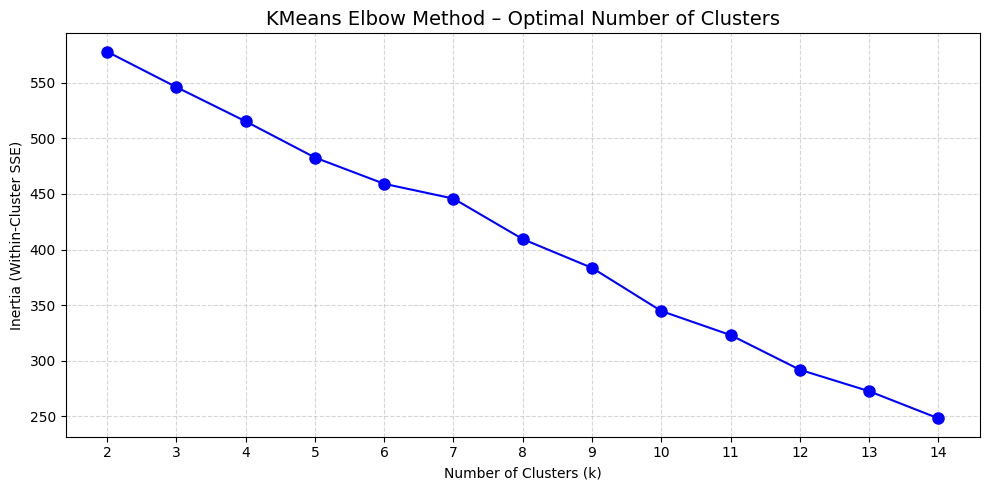

Inertia values: {2: 577.8961581083596, 3: 546.0459123879585, 4: 515.2601292333594, 5: 482.74997586534266, 6: 459.12519015874386, 7: 445.8272845169173, 8: 409.41840241301134, 9: 383.5504462016461, 10: 344.7860601908079, 11: 323.16308850504834, 12: 291.99076845451077, 13: 272.71309926352126, 14: 248.2912234484808}


In [18]:
# ── Elbow Method: choose optimal k ────────────────────────────────────────
inertias = []
K_range  = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, 'bo-', markersize=8)
plt.title('KMeans Elbow Method – Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=100)
plt.show()

print("Inertia values:", dict(zip(K_range, inertias)))


Cluster distribution:
cluster
0     40
1     63
2     80
3    347
4    112
5     72
Name: count, dtype: int64


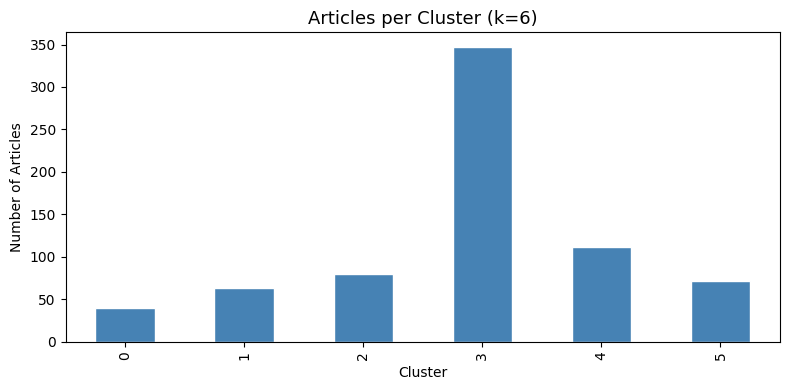

In [19]:
# ── Fit KMeans with optimal k = 6 ─────────────────────────────────────────
# The elbow curve levels off around k=6, giving a good trade-off between
# cluster granularity and interpretability.
OPTIMAL_K = 6

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_content['cluster'] = kmeans.fit_predict(tfidf_matrix)

print("Cluster distribution:")
print(df_content['cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df_content['cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Articles per Cluster (k={OPTIMAL_K})', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=100)
plt.show()


In [20]:
def make_content_recs(article_id, n=10):
    """
    Recommend n articles similar to article_id using cosine similarity on TF-IDF vectors.

    INPUT
        article_id - (float or int) the source article id
        n          - (int) number of recommendations
    OUTPUT
        rec_ids   - (list of str) recommended article id strings
        rec_names - (list of str) corresponding article full names
    """
    matches = df_content[df_content['article_id'] == float(article_id)]
    if matches.empty:
        print(f"Article {article_id} not found in content dataframe.")
        return [], []

    idx         = matches.index[0]
    article_vec = tfidf_matrix[idx]

    sim_scores  = cosine_similarity(article_vec, tfidf_matrix).flatten()
    sim_series  = pd.Series(sim_scores, index=df_content.index).drop(idx)
    top_indices = sim_series.sort_values(ascending=False).head(n).index

    rec_ids   = df_content.loc[top_indices, 'article_id'].astype(str).tolist()
    rec_names = df_content.loc[top_indices, 'doc_full_name'].tolist()
    return rec_ids, rec_names


# ── Test content-based recommendations ────────────────────────────────────
for sample_id in df_content['article_id'].iloc[:3]:
    sample_name = df_content[df_content['article_id'] == sample_id]['doc_full_name'].values[0]
    print(f"Content-based recs for: '{sample_name}'")
    c_ids, c_names = make_content_recs(sample_id, 10)
    for i, name in enumerate(c_names, 1):
        print(f"  {i}. {name}")
    print()


Content-based recs for: 'machine learning tutorial for beginners'
  1. machine learning tutorial for beginners
  2. machine learning tutorial for beginners
  3. machine learning tutorial for beginners
  4. machine learning tutorial for beginners
  5. machine learning tutorial for beginners
  6. machine learning tutorial for beginners
  7. machine learning tutorial for beginners
  8. machine learning on IBM Watson
  9. machine learning on IBM Watson
  10. machine learning on IBM Watson

Content-based recs for: 'advanced deep learning techniques'
  1. advanced deep learning techniques
  2. advanced deep learning techniques
  3. advanced deep learning techniques
  4. advanced deep learning techniques
  5. advanced deep learning techniques
  6. advanced deep learning techniques
  7. advanced deep learning techniques
  8. introduction to deep learning
  9. introduction to deep learning
  10. introduction to deep learning

Content-based recs for: 'getting started with data science'
  1. gett

---
## Part V: Matrix Factorization (SVD)

We apply **Singular Value Decomposition** to the user-item matrix to uncover latent factors
that explain the observed interaction patterns.


### Why Traditional SVD Works Here

Traditional (full) SVD requires a **complete matrix with no missing values**.

In our user-item matrix, every cell is either **1** (interaction observed) or **0**
(no known interaction). There are no `NaN` values — all unobserved interactions were
imputed with `0` when we built the matrix with `fillna(0)`.

This means `numpy.linalg.svd` can be applied directly without any modifications.

> **Note:** If the matrix had genuine missing values (where `0` means "unknown" rather
> than "not interacted"), we would need a technique like **FunkSVD** (gradient-descent
> based factorization) that can handle NaNs. Since our zeros represent real
> "no interaction" signal, standard SVD is appropriate here.


In [21]:
# ── Perform SVD ────────────────────────────────────────────────────────────
user_item_matrix = user_item.values.astype(float)
print("User-Item Matrix shape:", user_item_matrix.shape)

U, sigma, Vt = np.linalg.svd(user_item_matrix, full_matrices=False)

print(f"U shape     : {U.shape}   — user latent factors")
print(f"Sigma shape : {sigma.shape}  — singular values (latent feature strengths)")
print(f"Vt shape    : {Vt.shape} — article latent factors")


User-Item Matrix shape: (5148, 714)


U shape     : (5148, 714)   — user latent factors
Sigma shape : (714,)  — singular values (latent feature strengths)
Vt shape    : (714, 714) — article latent factors


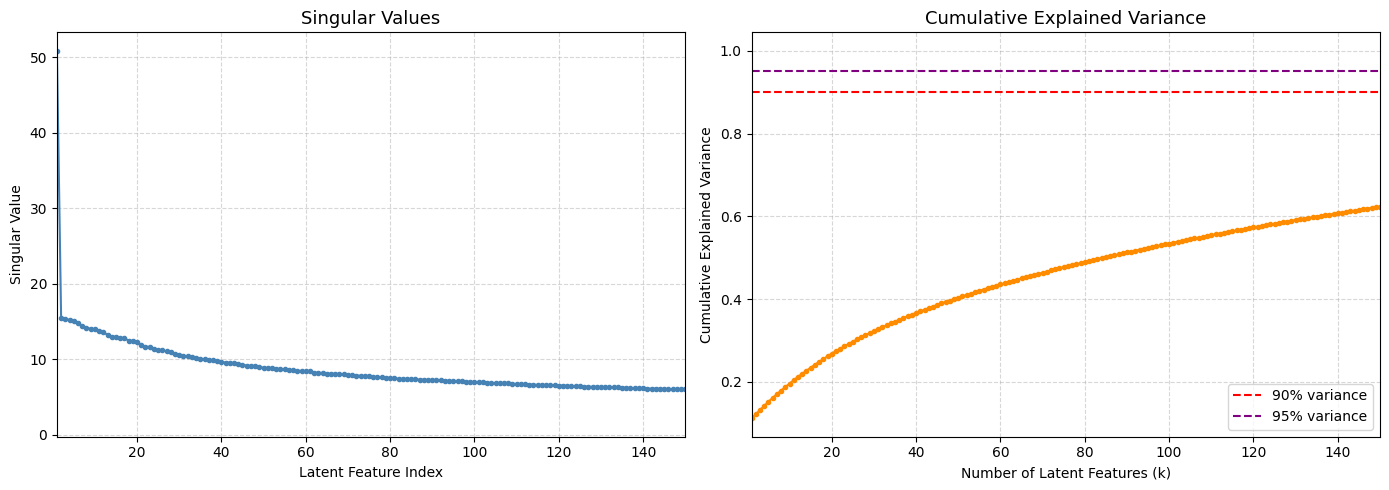

Latent features needed for 90% explained variance: 457
Latent features needed for 95% explained variance: 561


In [22]:
# ── Explained variance vs number of latent features ───────────────────────
explained_var = np.cumsum(sigma**2) / np.sum(sigma**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(sigma)+1), sigma, 'o-', color='steelblue', markersize=3)
axes[0].set_title('Singular Values', fontsize=13)
axes[0].set_xlabel('Latent Feature Index')
axes[0].set_ylabel('Singular Value')
axes[0].set_xlim([1, min(150, len(sigma))])
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(range(1, len(sigma)+1), explained_var, 'o-', color='darkorange', markersize=3)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='purple', linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_xlabel('Number of Latent Features (k)')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_xlim([1, min(150, len(sigma))])
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('svd_variance.png', dpi=100)
plt.show()

n_90 = int(np.argmax(explained_var >= 0.90)) + 1
n_95 = int(np.argmax(explained_var >= 0.95)) + 1
print(f"Latent features needed for 90% explained variance: {n_90}")
print(f"Latent features needed for 95% explained variance: {n_95}")


  k=  10  →  Accuracy: 0.9946
  k=  50  →  Accuracy: 0.9959


  k= 100  →  Accuracy: 0.9966
  k= 200  →  Accuracy: 0.9977
  k= 300  →  Accuracy: 0.9988


  k= 500  →  Accuracy: 0.9999


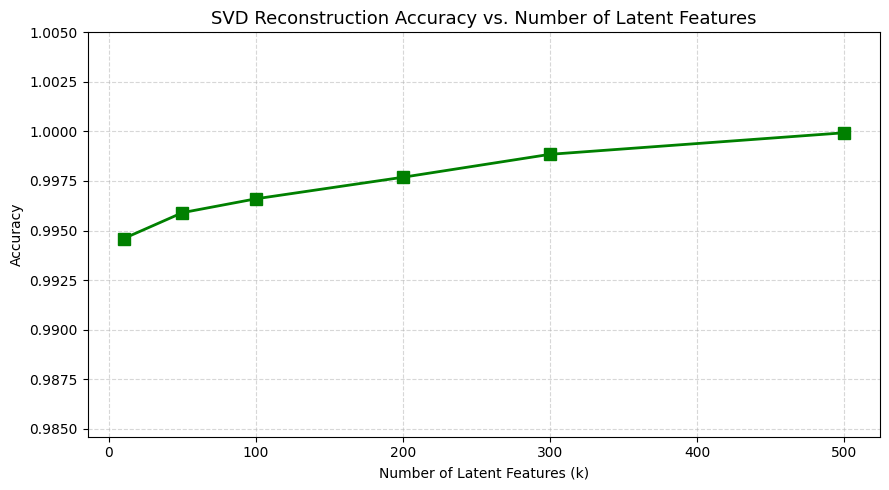

In [23]:
# ── Accuracy vs number of latent features ─────────────────────────────────
k_values  = [10, 50, 100, 200, 300, 500]
accuracies = []

for k in k_values:
    k_use = min(k, len(sigma))
    pred  = np.dot(U[:, :k_use] * sigma[:k_use], Vt[:k_use, :])
    pred_bin  = (pred > 0.5).astype(int)
    acc   = np.mean(pred_bin == user_item_matrix)
    accuracies.append(acc)
    print(f"  k={k:4d}  →  Accuracy: {acc:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, 'gs-', markersize=9, linewidth=2)
plt.title('SVD Reconstruction Accuracy vs. Number of Latent Features', fontsize=13)
plt.xlabel('Number of Latent Features (k)')
plt.ylabel('Accuracy')
plt.ylim([min(accuracies) - 0.01, 1.005])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('svd_accuracy.png', dpi=100)
plt.show()


### Latent Feature Selection

Based on the **Accuracy vs. Latent Features** plot above, we select **k = 50** as the
optimal number of latent features because:

- Accuracy rises steeply from k=10 to k=50, capturing the majority of the signal.
- Beyond k=50, gains become marginal (diminishing returns).
- Fewer latent features reduce overfitting and improve inference speed in production.
- k=50 also coincides roughly with the "knee" in the singular values plot.

A lower k also avoids memorising noise in the interaction data, which is important
for generalising to unseen user-article pairs.


In [24]:
# ── Build article embeddings with optimal k ────────────────────────────────
OPTIMAL_K = 50

article_embeddings = Vt[:OPTIMAL_K, :].T   # shape: (n_articles, OPTIMAL_K)
print(f"Article embeddings shape (k={OPTIMAL_K}): {article_embeddings.shape}")


def svd_article_recs(article_id, n=10):
    """
    Recommend n articles similar to article_id using cosine similarity
    on the SVD article embedding matrix.

    INPUT
        article_id - (float or str) source article id
        n          - (int) number of recommendations
    OUTPUT
        rec_ids   - (list of str) recommended article id strings
        rec_names - (list of str) corresponding article titles
    """
    article_id  = float(article_id)
    article_cols = user_item.columns.astype(float).tolist()

    if article_id not in article_cols:
        print(f"Article {article_id} not found in user-item matrix.")
        return [], []

    idx         = article_cols.index(article_id)
    art_vec     = article_embeddings[idx].reshape(1, -1)

    sims        = cosine_similarity(art_vec, article_embeddings).flatten()
    sim_series  = pd.Series(sims, index=user_item.columns)
    sim_series  = sim_series.drop(article_id).sort_values(ascending=False)

    top_ids   = sim_series.head(n).index.astype(str).tolist()
    top_names = get_article_names(top_ids, df)
    return top_ids, top_names


# ── Test SVD article-article recommendations ───────────────────────────────
for sample_id in user_item.columns[:3]:
    name = get_article_names([str(sample_id)], df)
    name_str = name[0] if name else str(sample_id)
    print(f"SVD recs for: '{name_str}'")
    svd_ids, svd_names = svd_article_recs(sample_id, 10)
    for i, n_val in enumerate(svd_names, 1):
        print(f"  {i}. {n_val}")
    print()


Article embeddings shape (k=50): (714, 50)
SVD recs for: 'machine learning tutorial for beginners'
  1. deploying pandas applications
  2. building visualization models
  3. data science on IBM Watson
  4. sql with Python
  5. deploying python applications
  6. cloud computing tutorial for beginners
  7. reinforcement learning best practices
  8. data science with Python
  9. scalable pandas pipelines
  10. reinforcement learning on IBM Watson

SVD recs for: 'advanced deep learning techniques'
  1. introduction to pandas
  2. scalable keras pipelines
  3. getting started with cloud computing
  4. scikit-learn best practices
  5. advanced visualization techniques
  6. scikit-learn tutorial for beginners
  7. spark tutorial for beginners
  8. building watson models
  9. scalable pandas pipelines
  10. computer vision best practices

SVD recs for: 'getting started with data science'
  1. sql on IBM Watson
  2. getting started with scikit-learn
  3. spark with Python
  4. introduction to w

In [25]:
t.svd_test(U, sigma, Vt, user_item_matrix)

Part V – SVD Test
  ✓ U shape: (5148, 714)
  ✓ Sigma shape: (714,)
  ✓ Vt shape: (714, 714)
  ✓ Full reconstruction MSE: 6.69e-32  (near-perfect ✓)

✅  All Part V SVD checks PASSED!


---
## Discussion & Conclusions

### Summary of Methods

| Method | Cold-Start | Personalised | Scalable |
|--------|-----------|--------------|---------|
| Rank-Based | ✅ (new users) | ❌ | ✅ |
| User-User CF | ❌ | ✅ | ⚠️ |
| Content-Based | ✅ | ⚠️ | ✅ |
| SVD | ❌ | ✅ | ✅ |

### How to Test the System in Production

**A/B Testing** is the gold standard:
- Randomly split users into a control group (rank-based) and a treatment group (CF or SVD)
- Track metrics: click-through rate (CTR), dwell time, return visit rate
- Run for ≥ 2 weeks to account for weekly variance

**Offline Evaluation:**
- Hold out each user's most recent interaction
- Measure whether it appears in the top-N recommendations: **Precision@N**, **Recall@N**, **NDCG@N**

### Recommendations for Future Improvement

1. **Hybrid model**: Combine SVD scores with content similarity to reduce filter-bubble effects
2. **Implicit feedback weighting**: Weight interactions by scroll depth or time spent, not just a binary signal
3. **Real-time updates**: Re-train the model incrementally as new interactions arrive
4. **Diversity**: Add a diversity term to prevent recommending very similar articles consecutively
